In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

CLASSES = ["DoS", "Spoofing", "Fuzzing", "Replay"]
DATA_DIR= Path("embeddings")
DATA_DIR_ABLATION = Path("..") / "CNN_Flag" / "embeddings"

### 1D CNN 

Two convolutional layers without dilation

### 15 Epochs

In [2]:
X_train = np.load(DATA_DIR / "X_train_15.npy")
y_train = np.load(DATA_DIR/ "y_train_15.npy")
X_test = np.load(DATA_DIR/ "X_test_15.npy")
y_test = np.load(DATA_DIR/ "y_test_15.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (235430, 192)
y_train: (235430,)
X_test: (100840, 192)
y_test: (100840,)


In [3]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    n_jobs=4,
    random_state=42
)

In [4]:
xgb_model.fit(X_train, y_train)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [5]:
y_pred = xgb_model.predict(X_test)

print("Predictions:", y_pred.shape)
print("Predicted classes:", np.unique(y_pred))

Predictions: (100840,)
Predicted classes: [0 1 2 3]


### Metrics

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [6]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")

Accuracy: 0.7856
Accuracy: 78.56%
Balanced_accuracy: 0.8185387709574834


In [7]:
print(classification_report(y_test, y_pred, target_names=CLASSES))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


              precision    recall  f1-score   support

         DoS       0.82      0.88      0.85     26414
    Spoofing       0.64      0.96      0.77     18918
     Fuzzing       0.77      0.60      0.68     36205
      Replay       1.00      0.84      0.91     19303

    accuracy                           0.79    100840
   macro avg       0.81      0.82      0.80    100840
weighted avg       0.80      0.79      0.78    100840

Macro F1: 0.800931993328476


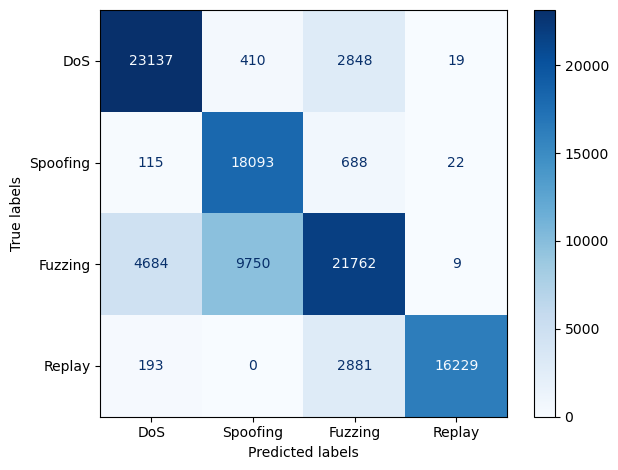

In [8]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

display.plot(cmap="Blues", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()


##### Random Forest

Same train/val/test split as XGBoost above.


In [9]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=4,
    random_state=42,
)

random_forest_model.fit(X_train, y_train)
print(random_forest_model)


RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=300,
                       n_jobs=4, random_state=42)


In [10]:
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions:", y_pred_rf.shape)
print("Predicted classes:", np.unique(y_pred_rf))


Predictions: (100840,)
Predicted classes: [0 1 2 3]


In [11]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")

Accuracy: 0.6935
Accuracy: 69.35%
Balanced_accuracy: 0.7262917574131841


In [12]:
print(classification_report(y_test, y_pred_rf, target_names=CLASSES))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))


              precision    recall  f1-score   support

         DoS       0.78      0.83      0.80     26414
    Spoofing       0.56      0.93      0.70     18918
     Fuzzing       0.62      0.49      0.55     36205
      Replay       1.00      0.65      0.79     19303

    accuracy                           0.69    100840
   macro avg       0.74      0.73      0.71    100840
weighted avg       0.72      0.69      0.69    100840

Macro F1: 0.7107027147102786


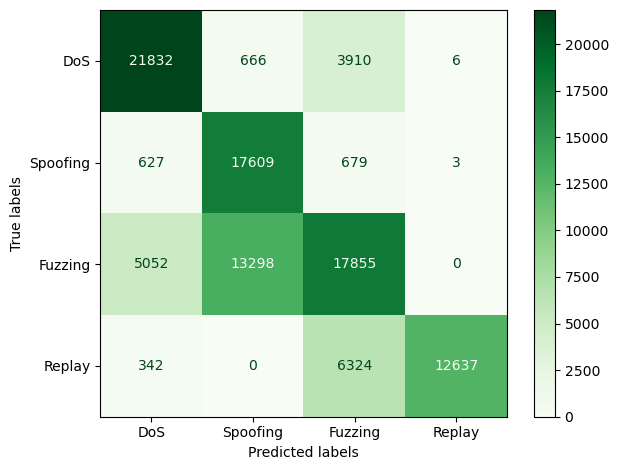

In [13]:
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

display.plot(cmap="Greens", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()


#### Comparison

In [14]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print()
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))


XGBoost
Accuracy: 0.7856108687028956
Balanced_accuracy: 0.8185387709574834
Macro F1: 0.800931993328476

Random Forest
Accuracy: 0.6935045616818722
Balanced_accuracy: 0.7262917574131841
Macro F1: 0.7107027147102786


## 1D CNN 
Three convolutional layers with dilation. 

### 15 Epochs

In [ ]:
X_train = np.load(DATA_DIR / "X_train_cnn_15.npy")
y_train = np.load(DATA_DIR/ "y_train_cnn_15.npy")
X_test = np.load(DATA_DIR / "X_test_cnn_15.npy")
y_test = np.load(DATA_DIR / "y_test_cnn_15.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (235430, 192)
y_train: (235430,)
X_test: (100840, 192)
y_test: (100840,)


In [3]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    n_jobs=4,
    random_state=42
)


In [4]:
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [5]:
y_pred = xgb_model.predict(X_test)

print("Predictions:", y_pred.shape)
print("Predicted classes:", np.unique(y_pred))

Predictions: (100840,)
Predicted classes: [0 1 2 3]


#### Metrics 

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [6]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")

Accuracy: 0.8753
Accuracy: 87.53%
Balanced_accuracy: 0.8746234547958223


In [7]:
print(classification_report(y_test, y_pred, target_names=CLASSES))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


              precision    recall  f1-score   support

         DoS       0.94      0.97      0.95     26414
    Spoofing       0.77      0.85      0.81     18918
     Fuzzing       0.84      0.84      0.84     36205
      Replay       0.98      0.84      0.90     19303

    accuracy                           0.88    100840
   macro avg       0.88      0.87      0.88    100840
weighted avg       0.88      0.88      0.88    100840

Macro F1: 0.8765829632705538


### Cross File Generalisation 

In [8]:
NPY = Path("cross_file_embeddings")

X_brake_warning = np.load(NPY / "brake_warning_cross_embedding.npy")
X_min_speedometer = np.load(NPY / "min_speedometer_attack_cross_embedding.npy")
X_power_steering = np.load(NPY / "power_steering_attack_cross_embedding.npy")
X_fuzzing_valid_ids = np.load(NPY / "fuzzing_valid_ids_cross_embedding.npy")
X_steering_angle_replay = np.load(NPY / "steering_angle_replay_cross_embedding.npy")

y_brake_warning = xgb_model.predict(X_brake_warning)
y_min_speedometer = xgb_model.predict(X_min_speedometer)
y_power_steering = xgb_model.predict(X_power_steering)
y_fuzzing_valid_ids = xgb_model.predict(X_fuzzing_valid_ids)
y_steering_angle_replay = xgb_model.predict(X_steering_angle_replay)


# 0 = DoS, 1 = Spoofing, 2 = Fuzzing, 3 = Replay
brake_warning_recall = (y_brake_warning == 1).mean()
min_speedometer_recall = (y_min_speedometer == 1).mean()
power_steering_recall = (y_power_steering == 1).mean()
fuzzing_valid_ids_recall = (y_fuzzing_valid_ids == 2).mean()
steering_angle_replay_recall = (y_steering_angle_replay == 3).mean()


print(f"Brake Warning Spoofing recall: {brake_warning_recall:.1%}")
print( f"Min Speedometer Spoofing recall: "f"{min_speedometer_recall:.1%}")
print(f"Power Steering Spoofing recall: "f"{power_steering_recall:.1%}")
print(f"Fuzzing valid IDs recall: "f"{fuzzing_valid_ids_recall:.1%}")
print(f"Steering-angle Replay recall: "f"{steering_angle_replay_recall:.1%}")

Brake Warning Spoofing recall: 5.0%
Min Speedometer Spoofing recall: 9.4%
Power Steering Spoofing recall: 1.7%
Fuzzing valid IDs recall: 94.7%
Steering-angle Replay recall: 12.0%


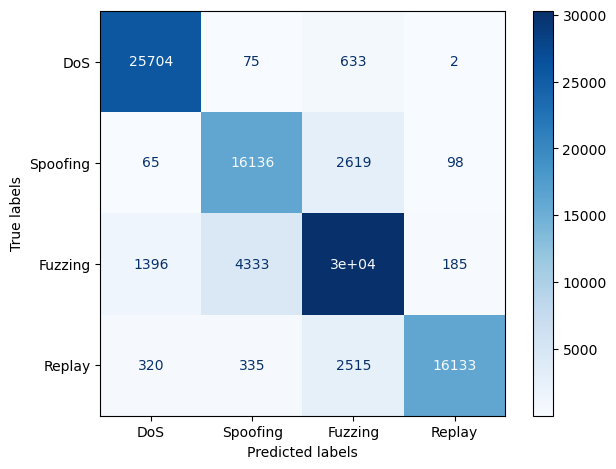

In [21]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)

display.plot(cmap="Blues", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()

### Random Forest 15 Epochs

In [ ]:
X_train = np.load(DATA_DIR/ "X_train_cnn_15.npy")
y_train = np.load(DATA_DIR / "y_train_cnn_15.npy")
X_test = np.load(DATA_DIR / "X_test_cnn_15.npy")
y_test = np.load(DATA_DIR / "y_test_cnn_15.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (235430, 192)
y_train: (235430,)
X_test: (100840, 192)
y_test: (100840,)


In [23]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=4,
    random_state=42,
)

random_forest_model.fit(X_train, y_train)
print(random_forest_model)


RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=300,
                       n_jobs=4, random_state=42)


In [24]:
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions:", y_pred_rf.shape)
print("Predicted classes:", np.unique(y_pred_rf))

Predictions: (100840,)
Predicted classes: [0 1 2 3]


#### Metrics 

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [25]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")

Accuracy: 0.8164
Accuracy: 81.64%
Balanced_accuracy: 0.7938473632393112


In [26]:
print(classification_report(y_test, y_pred_rf, target_names=CLASSES))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))


              precision    recall  f1-score   support

         DoS       0.92      0.93      0.93     26414
    Spoofing       0.80      0.74      0.77     18918
     Fuzzing       0.71      0.87      0.78     36205
      Replay       0.99      0.64      0.77     19303

    accuracy                           0.82    100840
   macro avg       0.86      0.79      0.81    100840
weighted avg       0.84      0.82      0.82    100840

Macro F1: 0.8127569837562957


In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
display.plot(cmap="Greens", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()

### Comparison

In [27]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print()
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))


XGBoost
Accuracy: 0.8752875842919476
Balanced_accuracy: 0.8746234547958223
Macro F1: 0.8765829632705538

Random Forest
Accuracy: 0.8163526378421262
Balanced_accuracy: 0.7938473632393112
Macro F1: 0.8127569837562957


### 1D CNN + 3L + Dilation

### 30 Epochs

In [ ]:
X_train = np.load(DATA_DIR / "X_train_cnn_30.npy")
y_train = np.load(DATA_DIR/ "y_train_cnn_30.npy")
X_test = np.load(DATA_DIR / "X_test_cnn_30.npy")
y_test = np.load(DATA_DIR / "y_test_cnn_30.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (235430, 192)
y_train: (235430,)
X_test: (100840, 192)
y_test: (100840,)


In [17]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    n_jobs=4,
    random_state=42
)


In [18]:
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [19]:
y_pred = xgb_model.predict(X_test)

print("Predictions:", y_pred.shape)
print("Predicted classes:", np.unique(y_pred))

Predictions: (100840,)
Predicted classes: [0 1 2 3]


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")

Accuracy: 0.8423
Accuracy: 84.23%
Balanced_accuracy: 0.841692815420028


In [21]:
print(classification_report(y_test, y_pred, target_names=CLASSES))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

              precision    recall  f1-score   support

         DoS       0.97      0.96      0.97     26414
    Spoofing       0.72      0.91      0.81     18918
     Fuzzing       0.78      0.80      0.79     36205
      Replay       0.97      0.69      0.81     19303

    accuracy                           0.84    100840
   macro avg       0.86      0.84      0.84    100840
weighted avg       0.86      0.84      0.84    100840

Macro F1: 0.8431196624230781


### Random Forest 30 Epochs

In [ ]:
X_train = np.load(DATA_DIR / "X_train_cnn_30.npy")
y_train = np.load(DATA_DIR/ "y_train_cnn_30.npy")
X_test = np.load(DATA_DIR / "X_test_cnn_30.npy")
y_test = np.load(DATA_DIR / "y_test_cnn_30.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (235430, 192)
y_train: (235430,)
X_test: (100840, 192)
y_test: (100840,)


In [25]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=4,
    random_state=42,
)

random_forest_model.fit(X_train, y_train)
print(random_forest_model)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=300,
                       n_jobs=4, random_state=42)


In [26]:
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions:", y_pred_rf.shape)
print("Predicted classes:", np.unique(y_pred_rf))

Predictions: (100840,)
Predicted classes: [0 1 2 3]


#### Metrics 

- Overall accuracy 
- Precision / Recall / F1 class
- Macro F1 
- Confusion matrix 


In [27]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")

Accuracy: 0.7984
Accuracy: 79.84%
Balanced_accuracy: 0.7699160932684151


In [28]:
print(classification_report(y_test, y_pred_rf, target_names=CLASSES))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))


              precision    recall  f1-score   support

         DoS       0.94      0.93      0.93     26414
    Spoofing       0.81      0.79      0.80     18918
     Fuzzing       0.68      0.87      0.76     36205
      Replay       0.99      0.49      0.65     19303

    accuracy                           0.80    100840
   macro avg       0.85      0.77      0.79    100840
weighted avg       0.83      0.80      0.79    100840

Macro F1: 0.7873895692260512


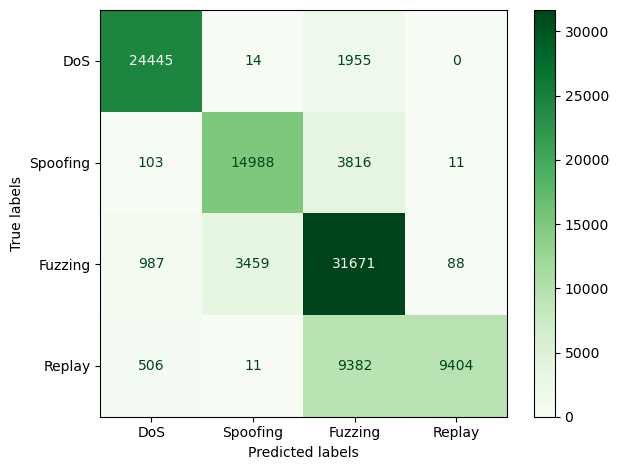

In [29]:
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
display.plot(cmap="Greens", colorbar=True)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.tight_layout()
plt.show()

#### Comparison

In [30]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred)}")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print()
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"Balanced_accuracy: {balanced_accuracy_score(y_test, y_pred_rf)}")
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))


XGBoost
Accuracy: 0.8423145577151924
Balanced_accuracy: 0.841692815420028
Macro F1: 0.8431196624230781

Random Forest
Accuracy: 0.7983736612455374
Balanced_accuracy: 0.7699160932684151
Macro F1: 0.7873895692260512
